In [1]:
import sys
import numpy as np
import os
import json
import shutil

# Add the directory containing instruments.py to the Python path
custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
sys.path.append(custom_module_path)

import plotting_rewrite as plotting
import instruments_jax as inst

h5_original_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/760nm_Fixed_EM_Gain_1_no_IMR_angle_Angles_PM90_Shared_Priors_HighProbA5Start_StretchMoveA5_AllSteps_WriteEvery1000_20000000_steps.h5"
h5_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/760nm_Fixed_EM_Gain_1_no_IMR_angle_Angles_PM90_Shared_Priors_HighProbA5Start_StretchMoveA5_AllSteps_WriteEvery1000_20000000_steps_copy.h5"
shutil.copy2(h5_original_file_path, h5_file_path)
txt_file_path = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/760_no_IMR_offset_fixed_EM_gain_1_no_retardance_constraints_iterate_on_any_improvement_from_broadband_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values.txt"
txt_save_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/760nm_Fixed_EM_Gain_1_no_IMR_angle_Angles_PM90_Shared_Priors_HighProbA5Start_StretchMoveA5_AllSteps_WriteEvery1000_20000000_steps.txt"

# Step 1: Defining System Dictionary

In [2]:
filter_wavelength = 760
wavelength_string = filter_wavelength
wavelength_index = 3
nsteps = 20000000
obs_mode = "MBI"

em_gain = 1.0

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta": 0},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": 0},
        },
    }
}

# Step 2: Loading Chains

dichroic.phi (waves): -0.07153 -0.08390/+0.02339
dichroic.epsilon (): 0.04218 -0.00499/+0.01225
dichroic.theta (): 14.75231 -7.78956/+9.90361
flc.phi (waves): 0.55254 -0.00748/+0.00625
flc.delta_theta (): 8.31555 -1.92157/+2.36089
optics.phi (waves): -0.32208 -0.01805/+0.01468
optics.epsilon (): 0.16608 -0.00328/+0.00293
optics.theta (): -85.34167 -3.56506/+4.33273
image_rotator.phi (waves): 0.50243 -0.00282/+0.00160
hwp.phi (waves): 0.49667 -0.00154/+0.00106
hwp.delta_theta (): -1.87013 -3.17499/+2.98478
lp.theta (): 1.05600 -5.14412/+4.29582
log_f (): -8.51932 -1.02290/+1.42762
Chain shape (nsteps, nwalkers, ndim): (131000, 28, 13)


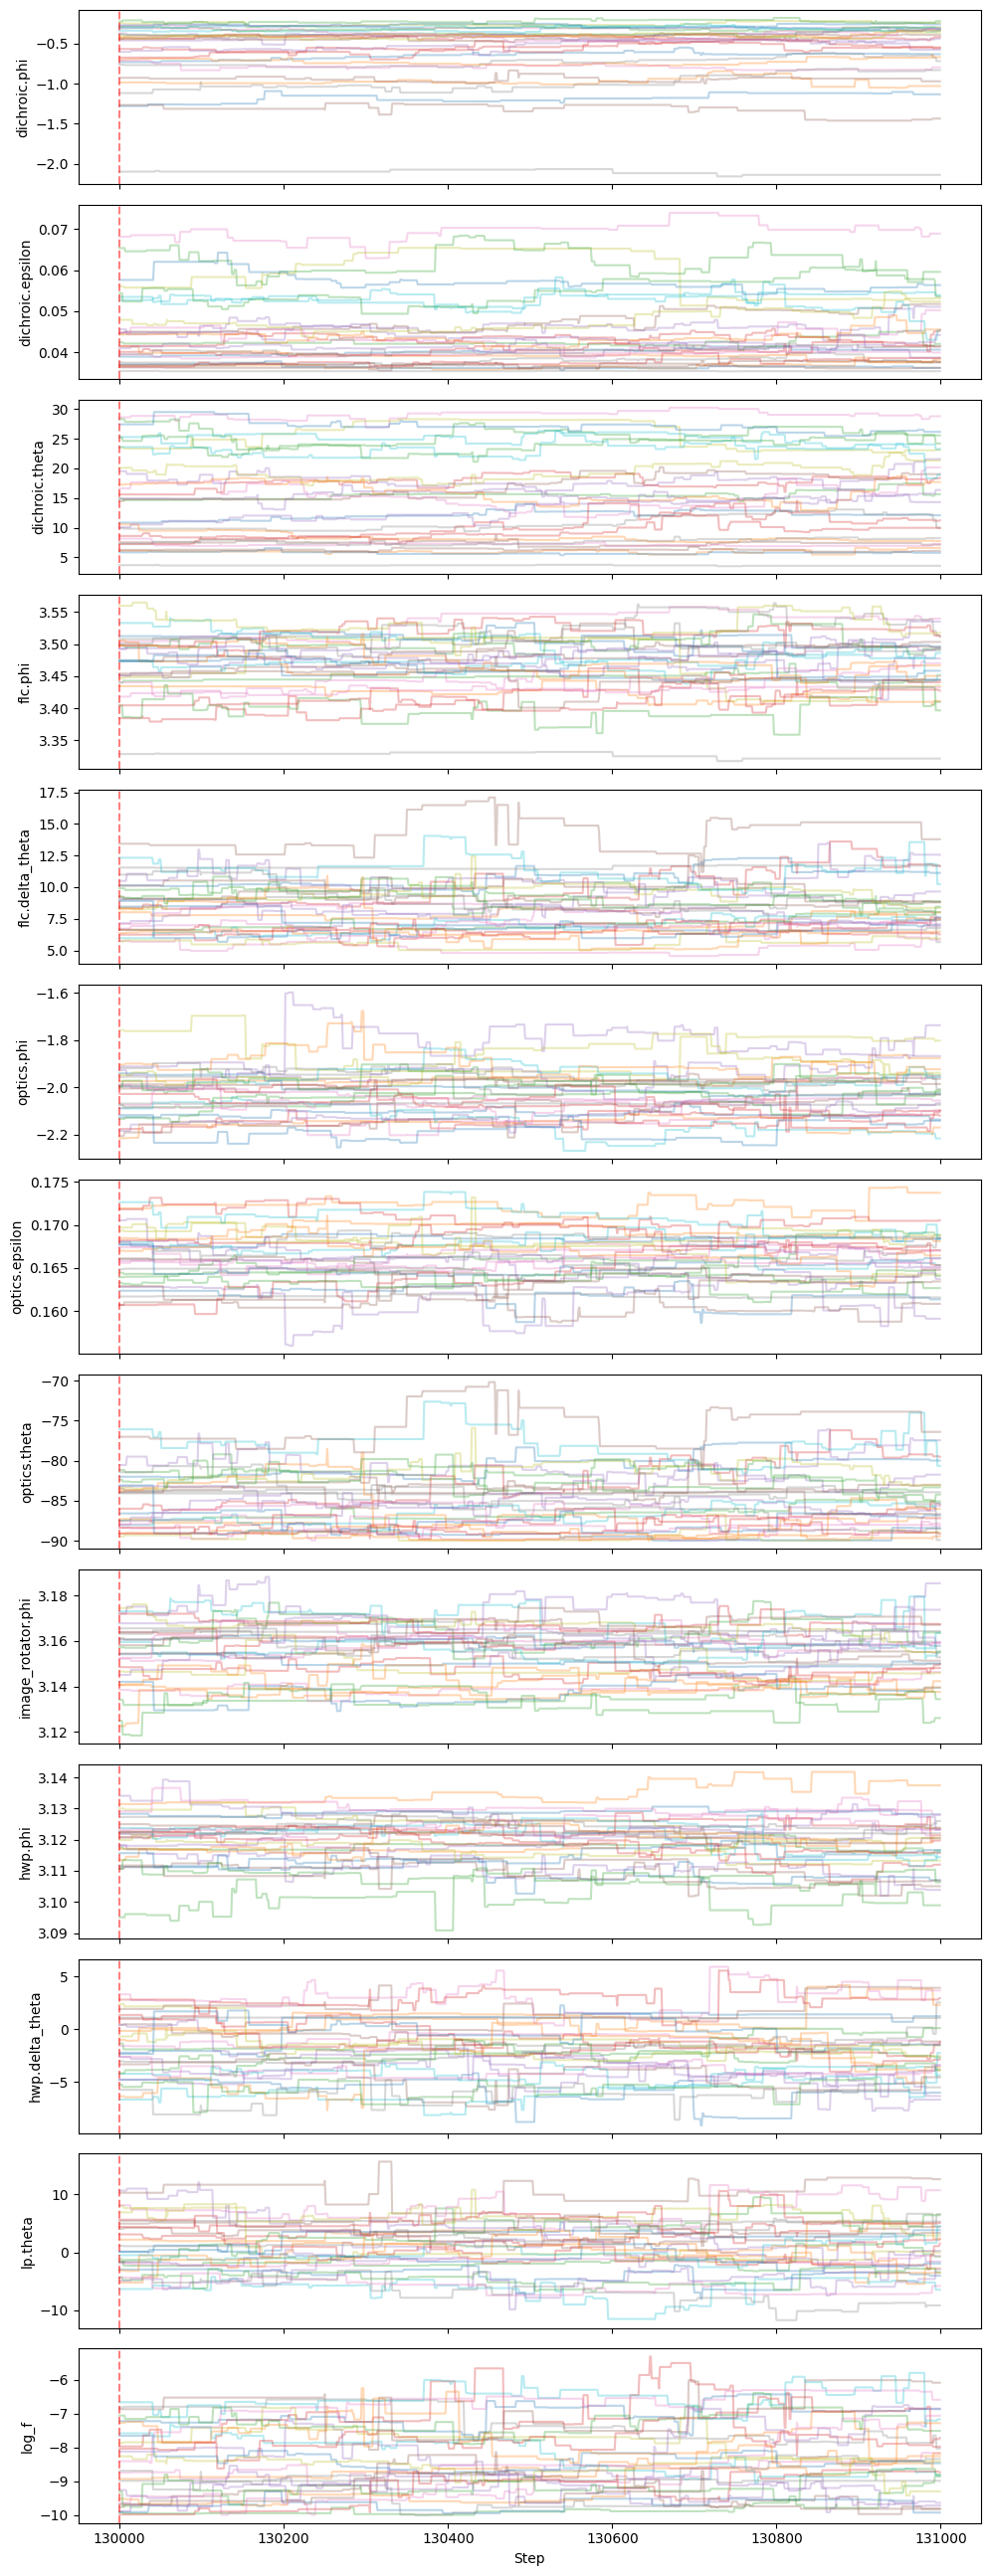

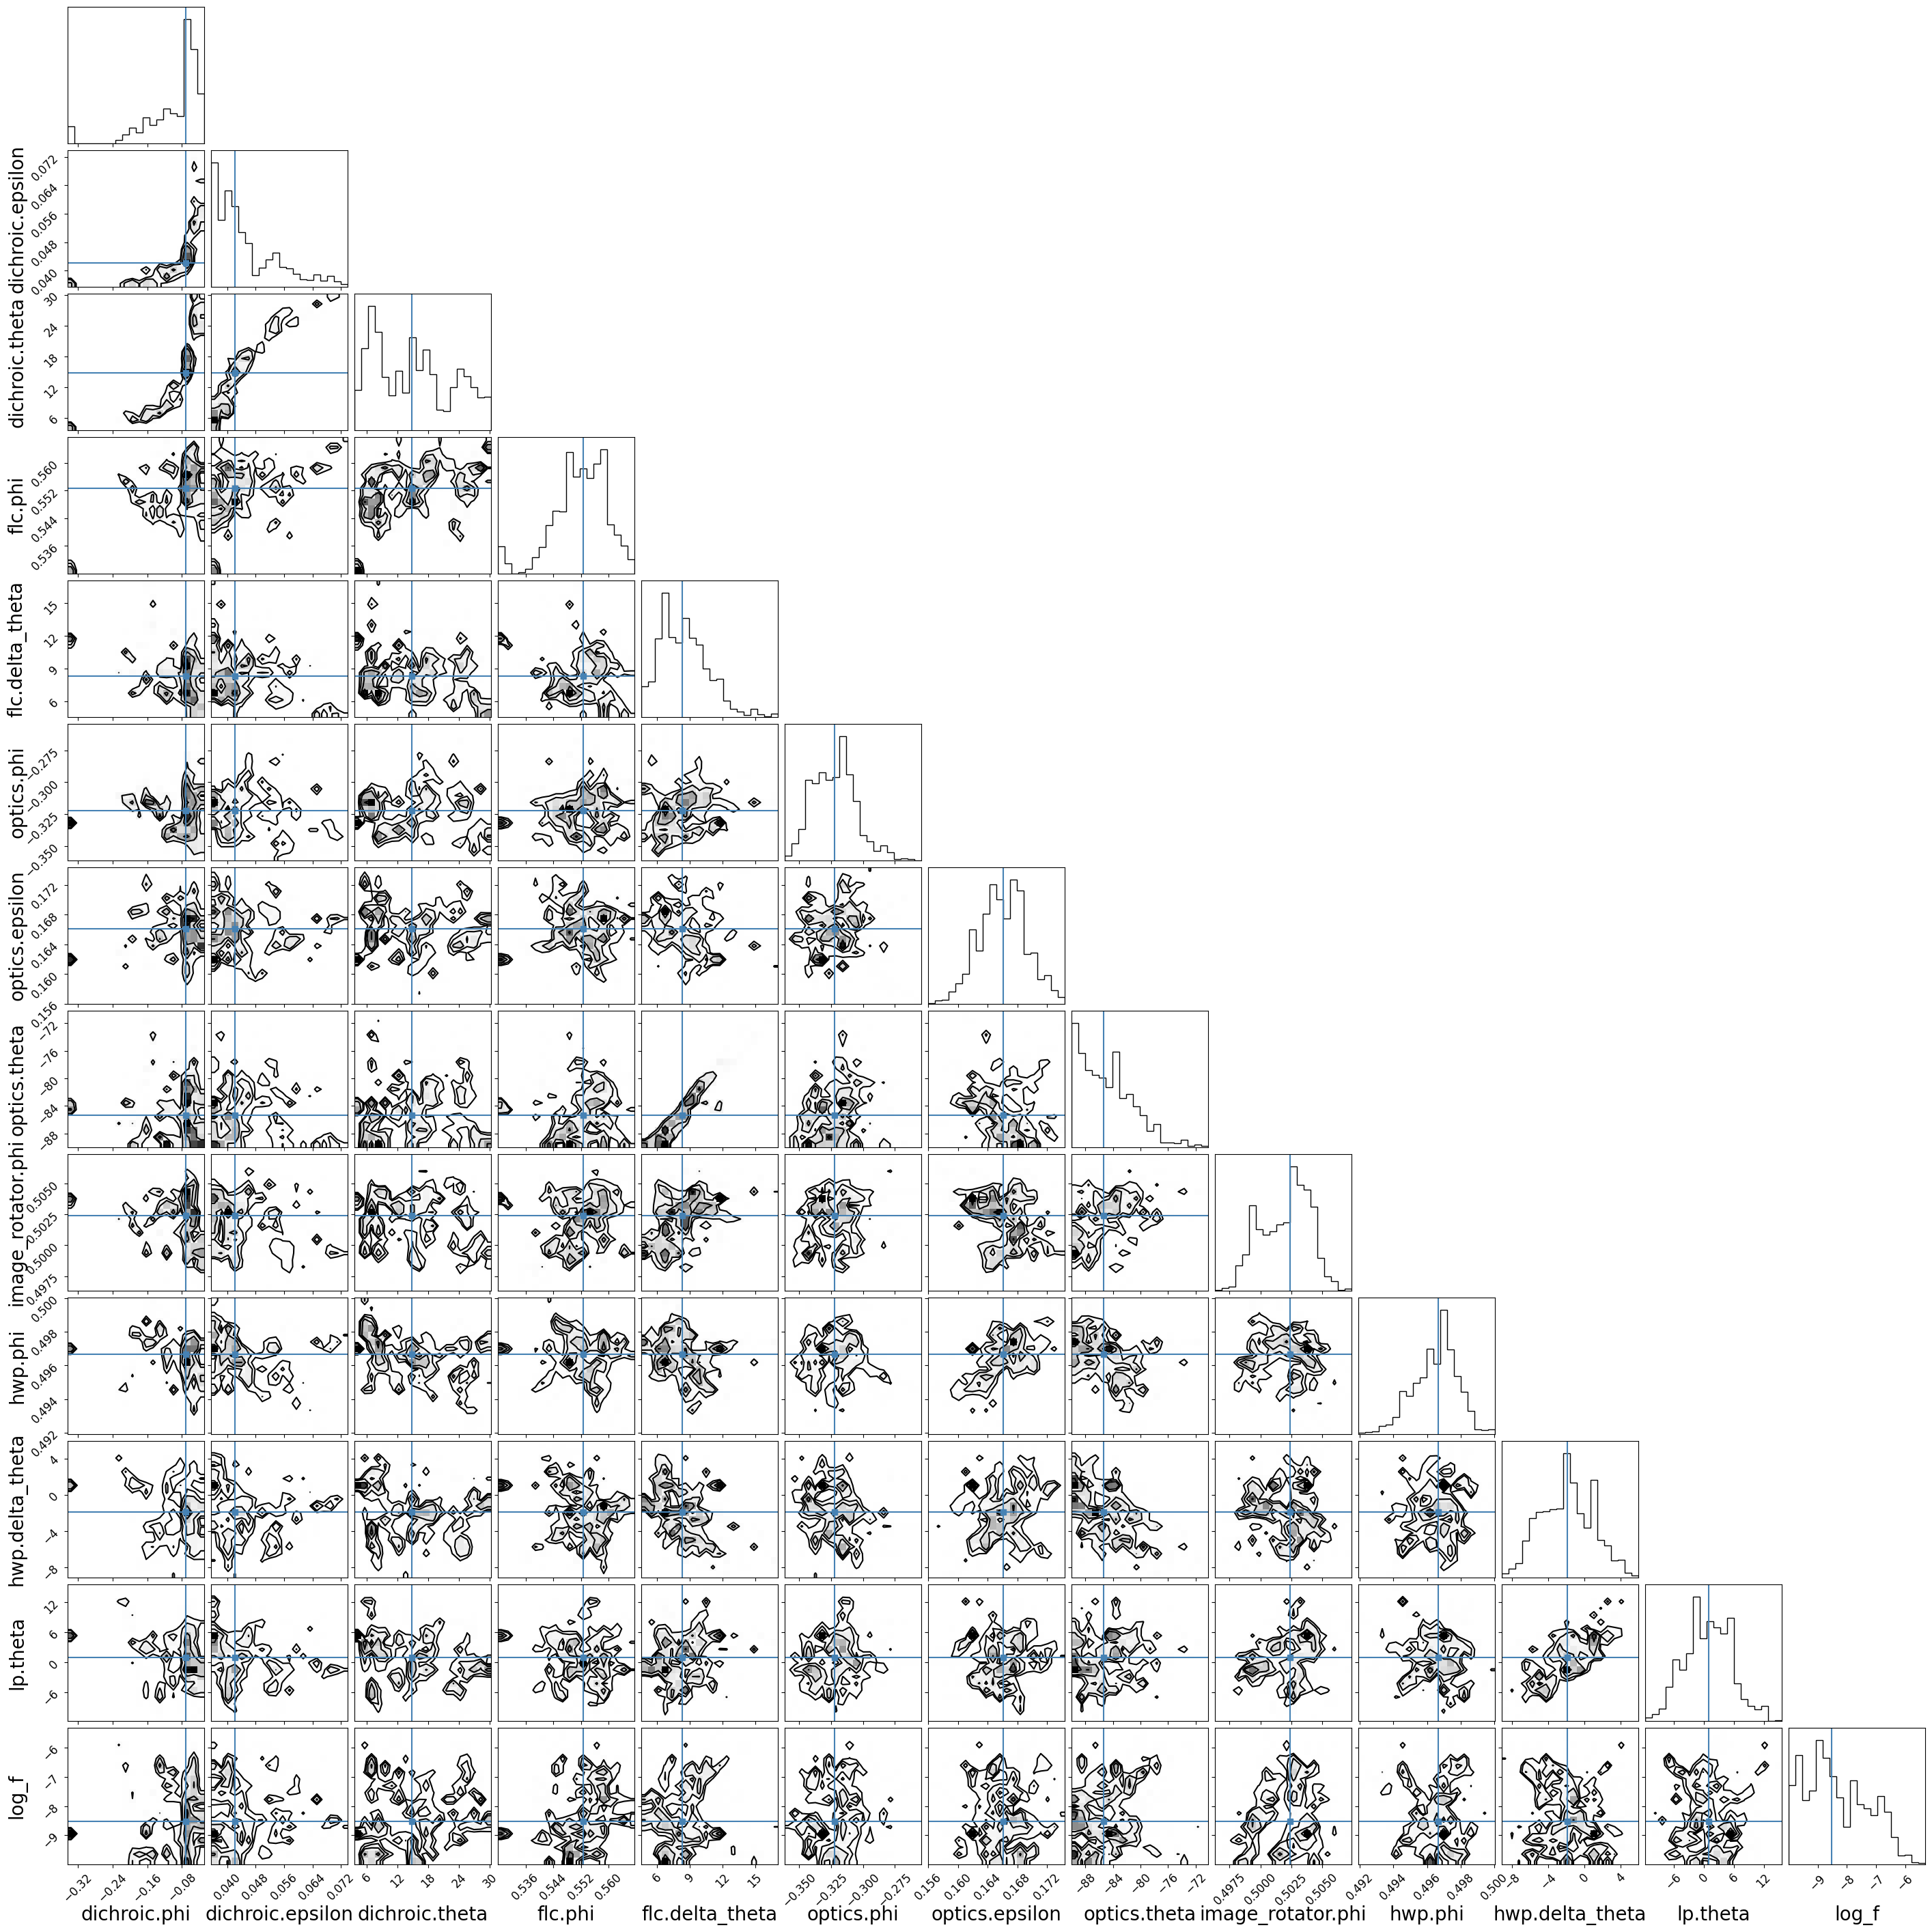

In [3]:
chain, names = plotting.load_chain_and_labels(h5_file_path, txt_file_path, include_logf = True, copy_file=True)
chain_step_range = (130000, 131000)
corner_plot_step_range = (130000, 131000)

# Print median with uneven 16th/84th percentile offsets for each parameter
plotting.summarize_posteriors(
    chain,
    names,
    system_dict,
    step_range=corner_plot_step_range,
    txt_save_file_path=txt_save_file_path,
    txt_file_path=txt_file_path,
    summary_mode="median",
    error_mode="percentile",
)

# Check chain shape after loading
print("Chain shape (nsteps, nwalkers, ndim):", chain.shape)

# Plot trace plots for MCMC chains
plotting.plot_trace(chain, names, step_range=chain_step_range, max_walkers=100)

# Plot corner plot from flattened chain
plotting.plot_corner_flat(chain, names, step_range=corner_plot_step_range)


## Step 2.5: Autocorrelation Time Diagnostics

In [4]:
import emcee

# Use the full loaded chain by default. Set a different range to estimate tau after burn-in.
autocorr_step_range = (0, None)
autocorr_thin = 1
autocorr_tol = 0  # Use 50 for emcee's usual convergence check; 0 always returns an estimate.

act_start, act_end = autocorr_step_range
if act_end is None:
    act_end = chain.shape[0]

if act_start < 0 or act_end > chain.shape[0] or act_start >= act_end:
    raise ValueError(f"Invalid autocorr_step_range {autocorr_step_range} for chain with {chain.shape[0]} steps.")

act_chain = chain[act_start:act_end:autocorr_thin, :, :]
if act_chain.shape[0] < 2:
    raise ValueError("Autocorrelation calculation needs at least two saved steps.")

autocorr_tau = emcee.autocorr.integrated_time(act_chain, tol=autocorr_tol, quiet=True)
autocorr_tau_steps = autocorr_tau * autocorr_thin
autocorr_nsteps = act_end - act_start
autocorr_neff = act_chain.shape[0] * act_chain.shape[1] / autocorr_tau
recommended_burn_in = int(2 * np.max(autocorr_tau_steps))
recommended_thinning = max(1, int(0.5 * np.min(autocorr_tau_steps)))

print(f"Autocorrelation step range: {act_start} to {act_end} (thin={autocorr_thin})")
print(f"{'parameter':<35} {'tau [steps]':>12} {'nsteps/tau':>12} {'N_eff':>12}")
for name, tau_steps, neff in zip(names, autocorr_tau_steps, autocorr_neff):
    print(f"{name:<35} {tau_steps:12.1f} {autocorr_nsteps / tau_steps:12.1f} {neff:12.0f}")

print(f"Mean tau: {np.mean(autocorr_tau_steps):.1f} steps")
print(f"Max tau: {np.max(autocorr_tau_steps):.1f} steps")
print(f"Recommended burn-in: {recommended_burn_in} steps")
print(f"Recommended thinning: {recommended_thinning} steps")


Autocorrelation step range: 0 to 131000 (thin=1)
parameter                            tau [steps]   nsteps/tau        N_eff
dichroic.phi                             12913.5         10.1          284
dichroic.epsilon                         11450.1         11.4          320
dichroic.theta                           13171.7          9.9          278
flc.phi                                   3697.6         35.4          992
flc.delta_theta                           3463.5         37.8         1059
optics.phi                                3153.4         41.5         1163
optics.epsilon                            3007.9         43.6         1219
optics.theta                              3964.7         33.0          925
image_rotator.phi                         2987.5         43.8         1228
hwp.phi                                   2940.2         44.6         1248
hwp.delta_theta                           3238.0         40.5         1133
lp.theta                                  2830.4   

# Step 2.6: Apply Recommended Burn-in and Thinning


Using burn-in = 26343 saved steps and thinning = 1415 saved steps.
Posterior chain shape (nthinned_steps, nwalkers, ndim): (74, 28, 13)
Original saved steps included: 26343 to 129638 (74 thinned samples per walker).
dichroic.phi (waves): -0.09520 -0.09209/+0.04064
dichroic.epsilon (): 0.04003 -0.00285/+0.00782
dichroic.theta (): 10.82631 -4.52333/+8.96221
flc.phi (waves): 0.55202 -0.00811/+0.00640
flc.delta_theta (): 8.54771 -2.09200/+2.49946
optics.phi (waves): -0.32103 -0.01691/+0.01853
optics.epsilon (): 0.16611 -0.00336/+0.00311
optics.theta (): -85.47339 -3.30709/+5.01895
image_rotator.phi (waves): 0.50229 -0.00235/+0.00190
hwp.phi (waves): 0.49644 -0.00151/+0.00156
hwp.delta_theta (): -1.62189 -3.03729/+2.91143
lp.theta (): 1.44178 -4.54415/+4.69123
log_f (): -8.23442 -1.20911/+1.33674


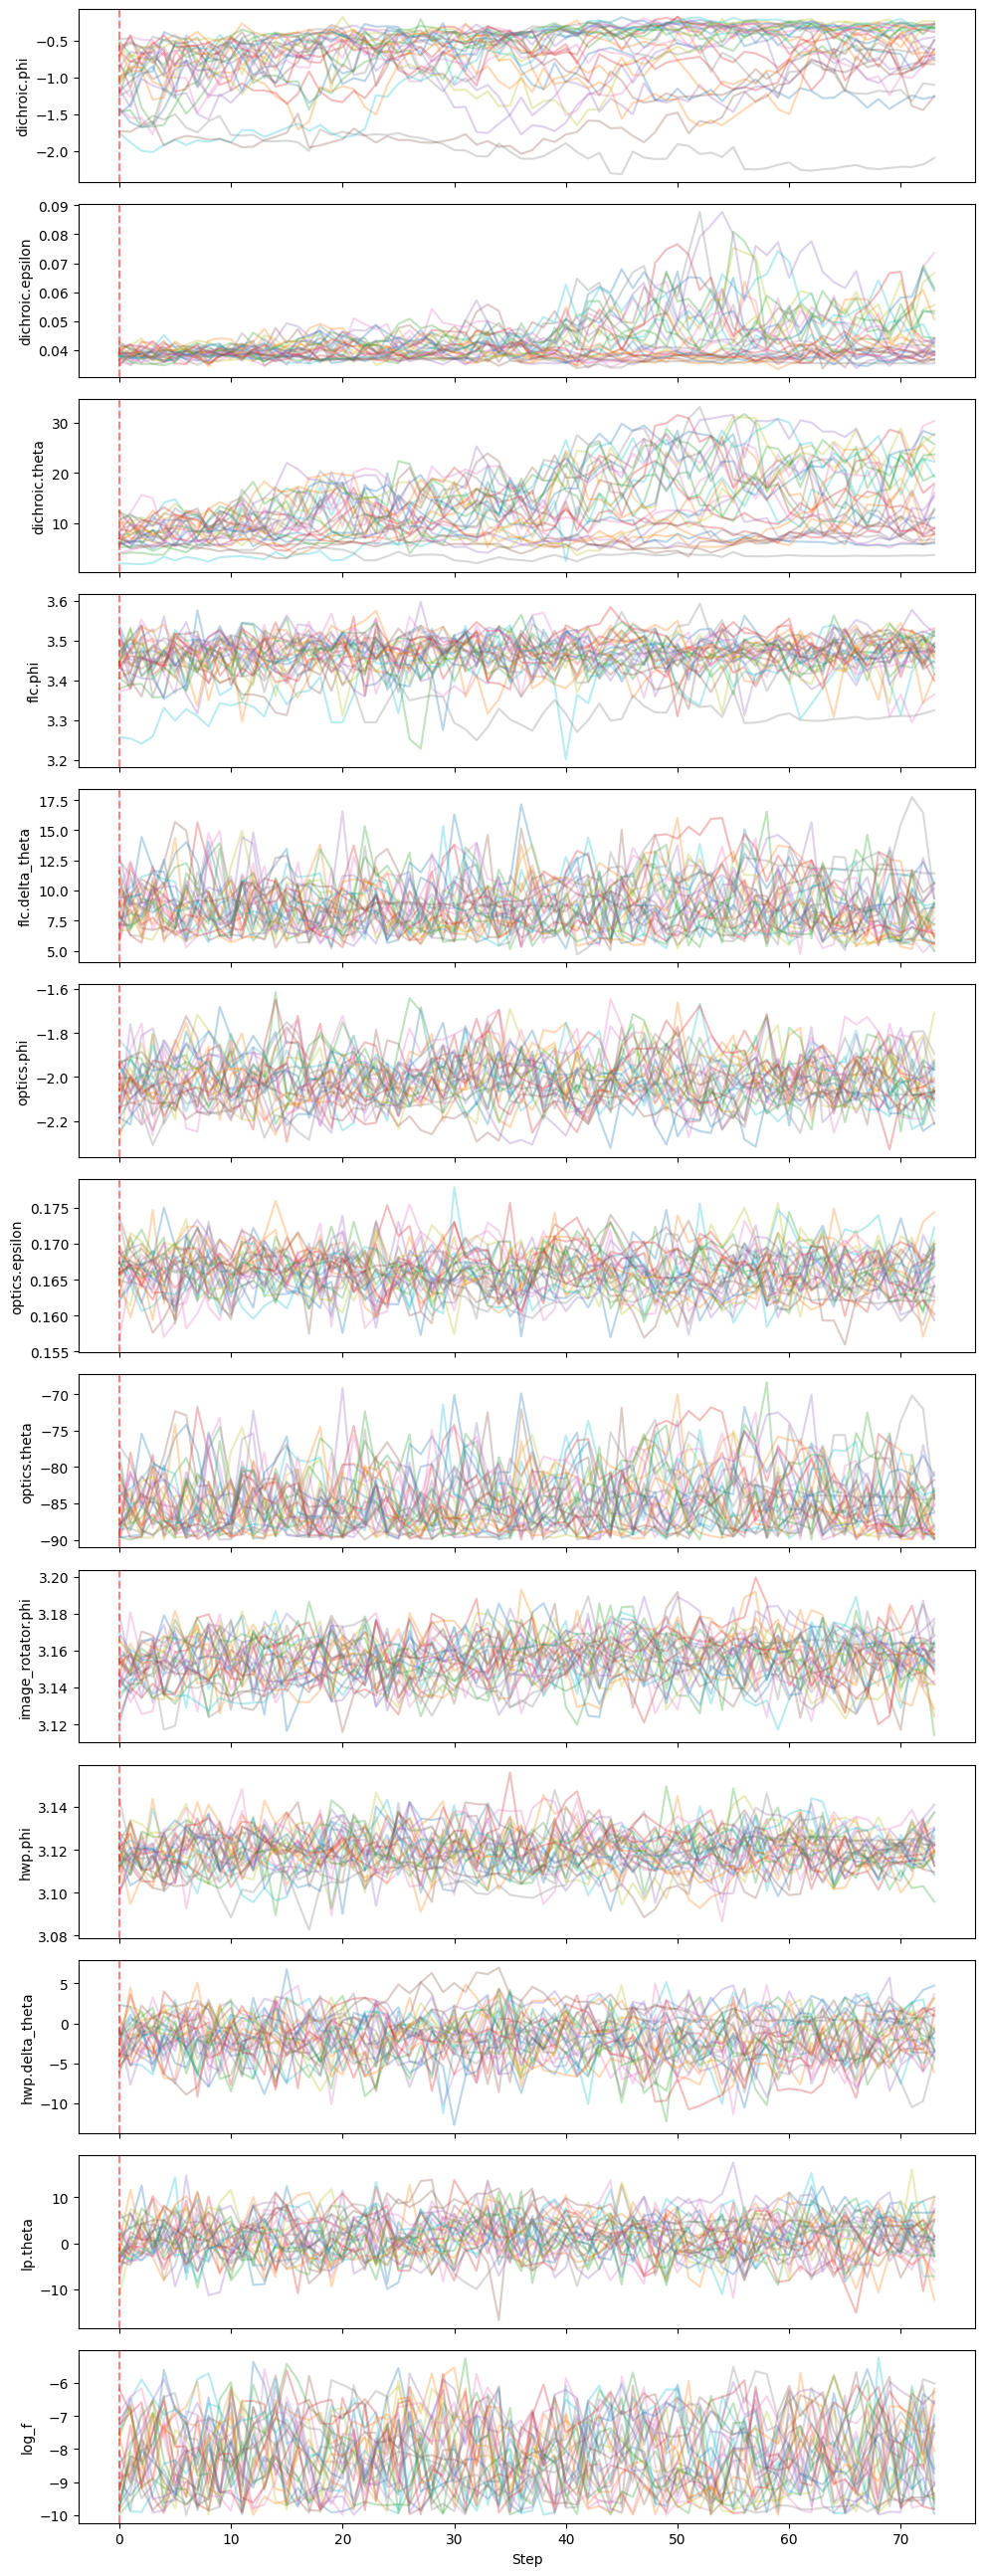

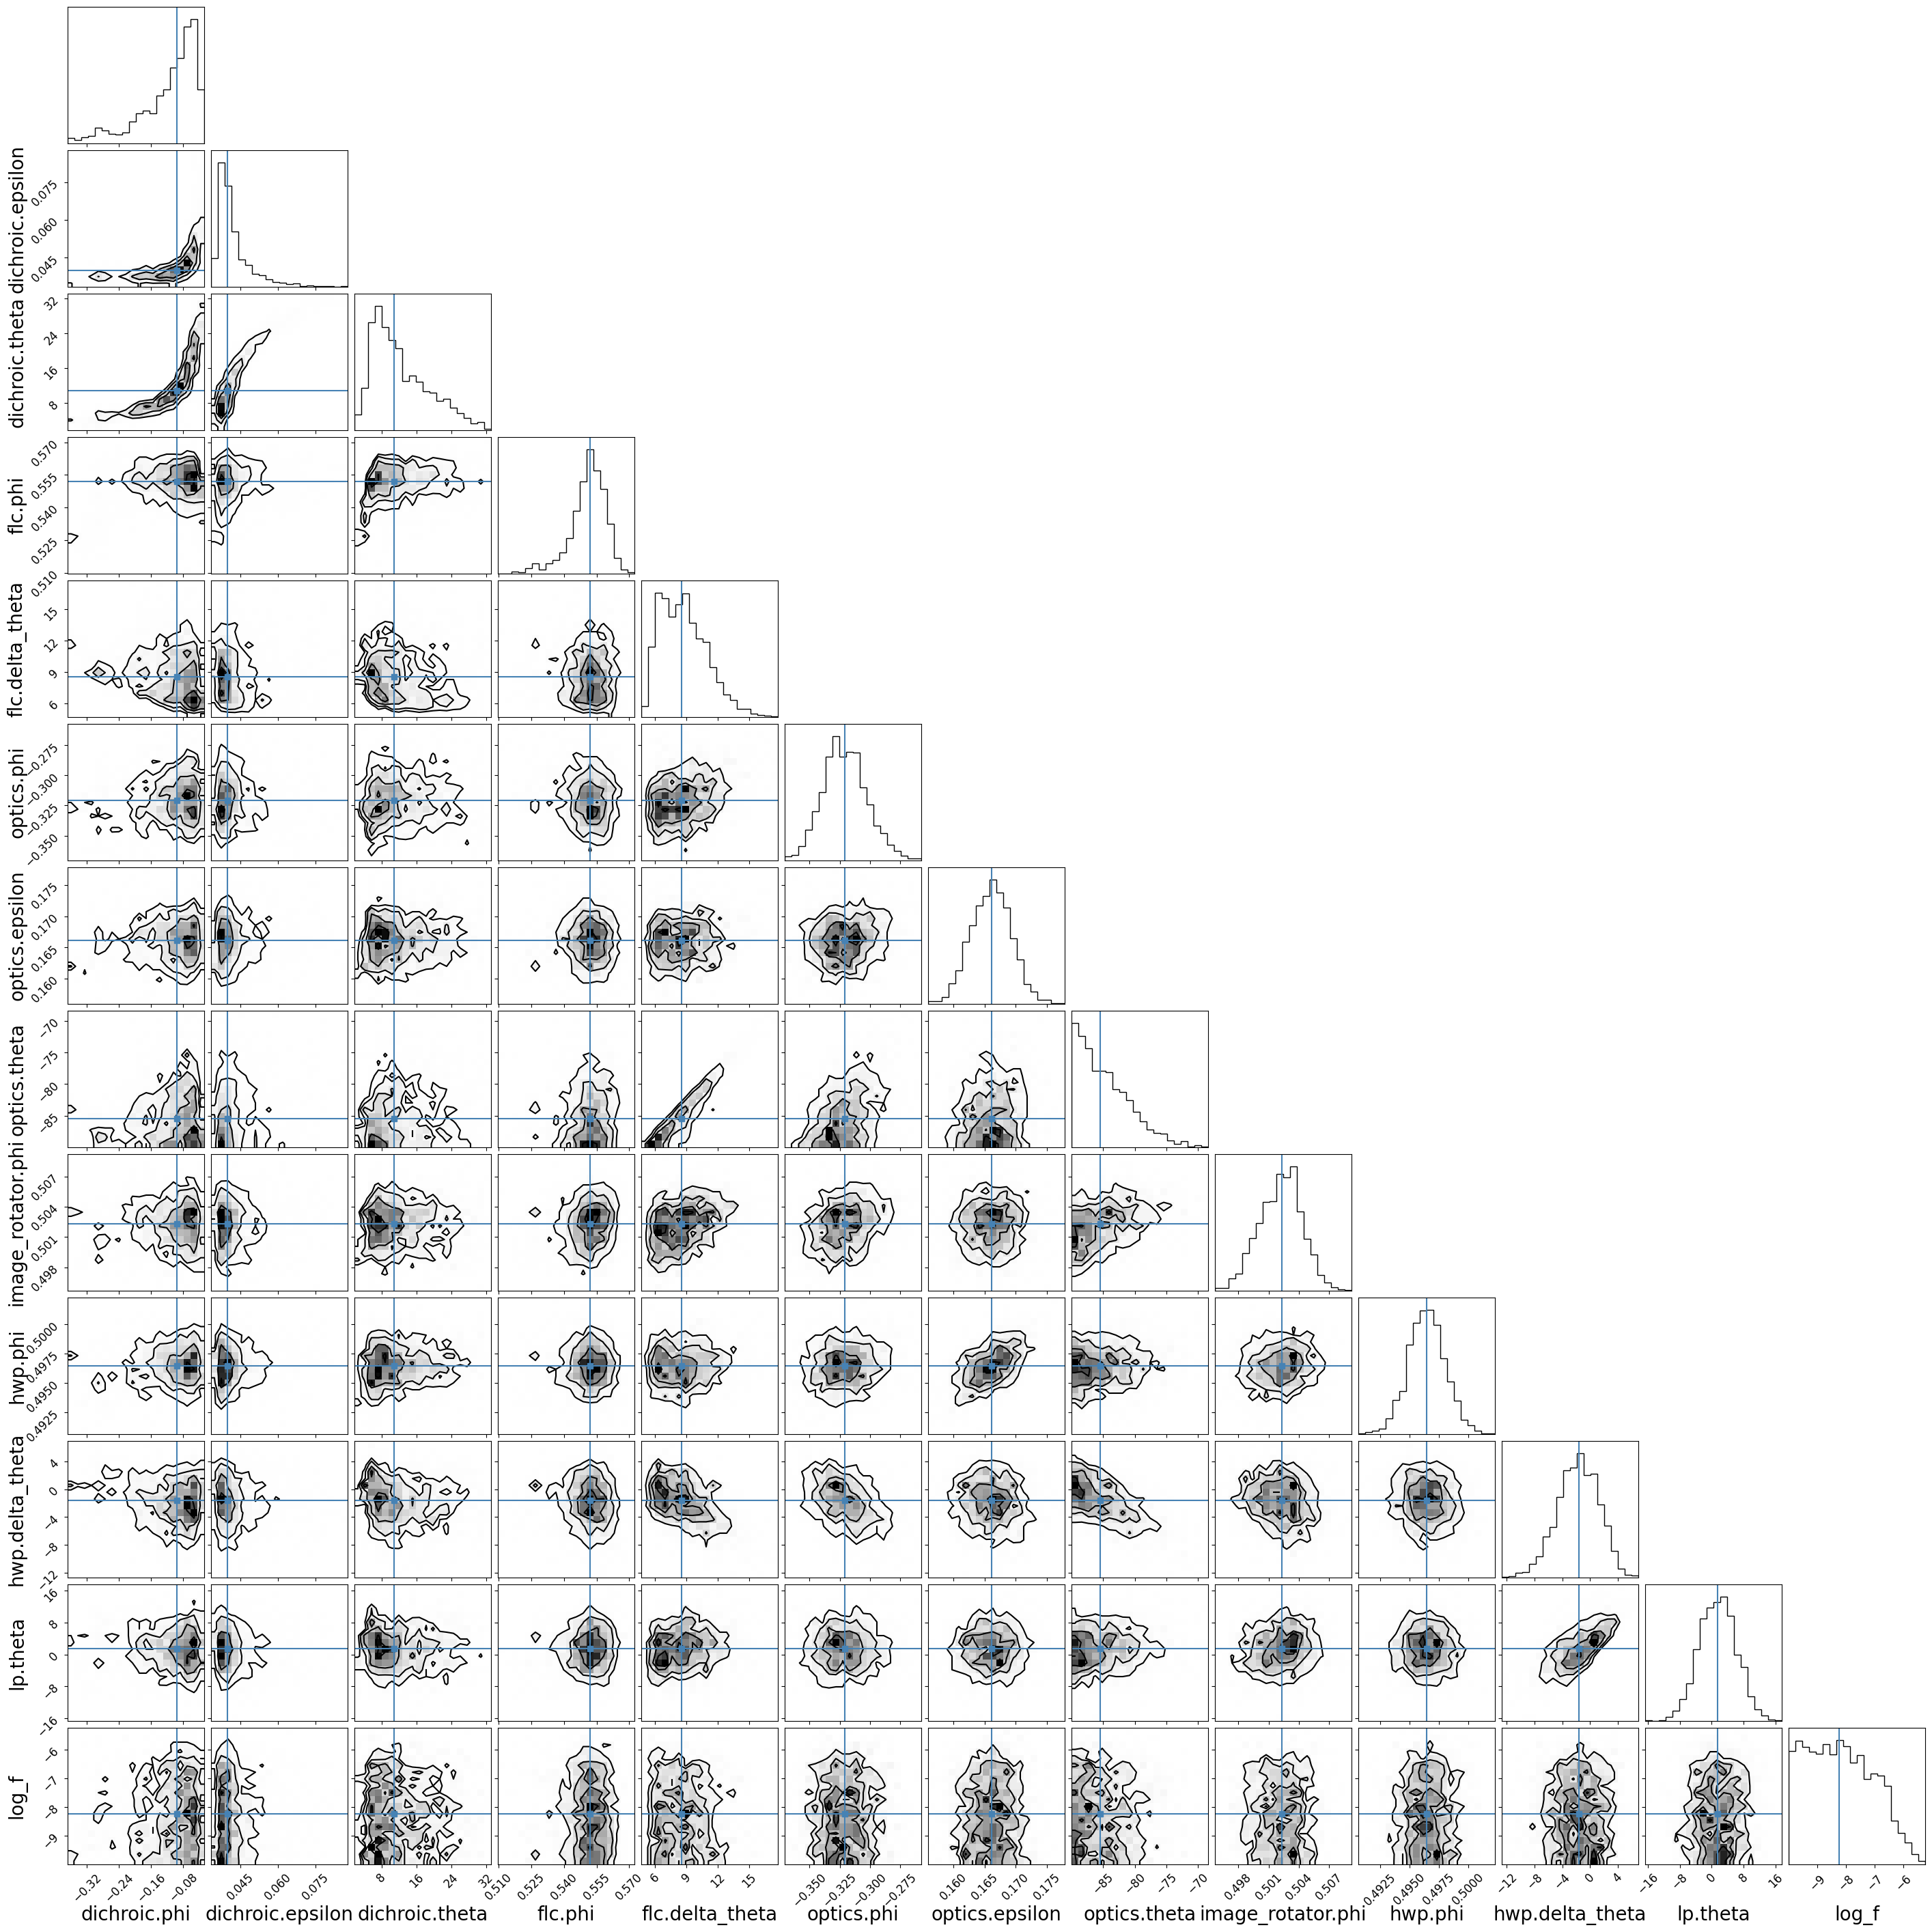

In [5]:
burn_in = recommended_burn_in
thinning = recommended_thinning

if burn_in < 0 or burn_in >= chain.shape[0]:
    raise ValueError(f"Invalid burn_in {burn_in} for chain with {chain.shape[0]} steps.")
if thinning < 1:
    raise ValueError(f"Invalid thinning {thinning}; thinning must be >= 1.")

posterior_chain = chain[burn_in::thinning, :, :]
posterior_step_numbers = np.arange(burn_in, chain.shape[0], thinning)
if posterior_chain.shape[0] < 1:
    raise ValueError("No posterior samples remain after applying burn-in and thinning.")

chain_step_range = (0, None)
corner_plot_step_range = (0, None)

print(f"Using burn-in = {burn_in} saved steps and thinning = {thinning} saved steps.")
print("Posterior chain shape (nthinned_steps, nwalkers, ndim):", posterior_chain.shape)
print(
    f"Original saved steps included: {posterior_step_numbers[0]} to "
    f"{posterior_step_numbers[-1]} ({posterior_chain.shape[0]} thinned samples per walker)."
)

# Print posterior summary with uneven 16th/84th percentile offsets and save the median-fit text file.
plotting.summarize_posteriors(
    posterior_chain,
    names,
    system_dict,
    step_range=corner_plot_step_range,
    txt_save_file_path=txt_save_file_path,
    txt_file_path=txt_file_path,
    summary_mode="median",
    error_mode="percentile",
)

# Plot trace plots after burn-in/thinning.
plotting.plot_trace(posterior_chain, names, step_range=chain_step_range, max_walkers=100)

# Plot corner plot from the flattened thinned posterior chain.
plotting.plot_corner_flat(posterior_chain, names, step_range=corner_plot_step_range)


# Step 3: Plot median configuration of posteriors

In [6]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)

In [7]:
# Loading in median parameters
with open(txt_save_file_path, "r") as f:
    past_fit = json.load(f)

# print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = past_fit["image_rotator"].get("delta_theta", 0)
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
delta_dichroic = past_fit["dichroic"]["phi"]
epsilon_dichroic = past_fit["dichroic"]["epsilon"]
rot_dichroic = past_fit["dichroic"]["theta"]

print(delta_HWP)

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_dichroic * 2 * np.pi,
                "epsilon": epsilon_dichroic,
                "theta": rot_dichroic,
            },
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_FLC * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": rot_FLC,
            },
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_opts * 2 * np.pi,
                "epsilon": epsilon_opts,
                "theta": rot_opts,
            },
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_derot * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": offset_derot,
            },
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_HWP * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": offset_HWP,
            },
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())


0.4964416388918076
[[0.4124155  0.41189331 0.02074719 0.        ]
 [0.4124155  0.41189331 0.02074719 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


logl value: 86.45129583040374


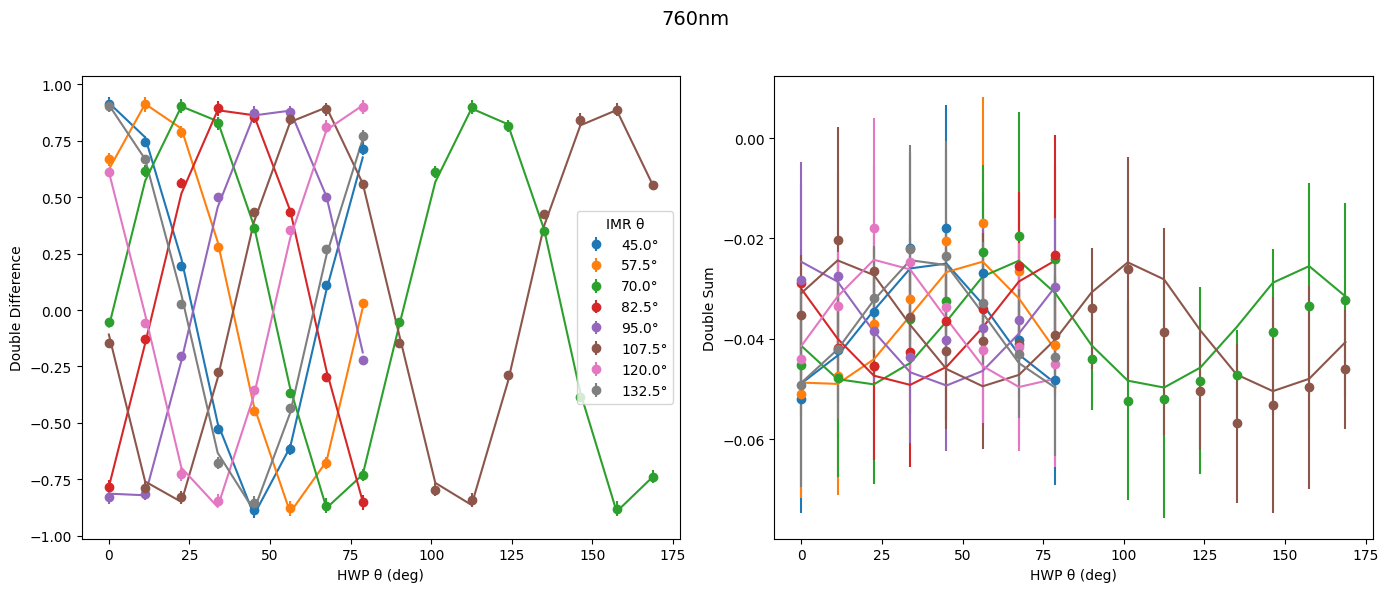

In [8]:
# Fittin for all parameters

p0 = {
    "wollaston": {"transmission_ratio": em_gain}, 
}

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
# updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 4: Plotting Random Chains for Fitting (UNDER CONSTRUCTION)

Plotting 100 random chain samples from steps 0 to 131000.
Selected (step, walker) pairs:
[(57266, 17), (123179, 12), (87745, 4), (61139, 19), (59009, 2), (101966, 23), (20211, 19), (42682, 20), (21644, 18), (93987, 9), (23913, 14), (65209, 24), (56723, 14), (107779, 18), (48529, 22), (91352, 25), (109025, 20), (26391, 23), (116311, 14), (126742, 14), (29767, 20), (120849, 24), (116997, 5), (16782, 14), (21050, 1), (110004, 16), (104233, 7), (24820, 15), (99545, 13), (18307, 16), (31382, 1), (72649, 8), (91734, 10), (68967, 2), (71449, 23), (37770, 26), (118624, 3), (102972, 1), (84344, 17), (100587, 7), (12069, 16), (110261, 11), (71599, 21), (50759, 16), (58086, 4), (62316, 26), (82498, 22), (8897, 10), (99706, 26), (29724, 26), (85746, 16), (117649, 8), (89478, 12), (48029, 19), (58384, 6), (60644, 21), (121403, 19), (67231, 4), (96381, 7), (97381, 4), (52715, 6), (48573, 14), (101385, 14), (10000, 24), (83415, 21), (89406, 24), (108417, 23), (11258, 16), (36254, 25), (12736, 18), (1

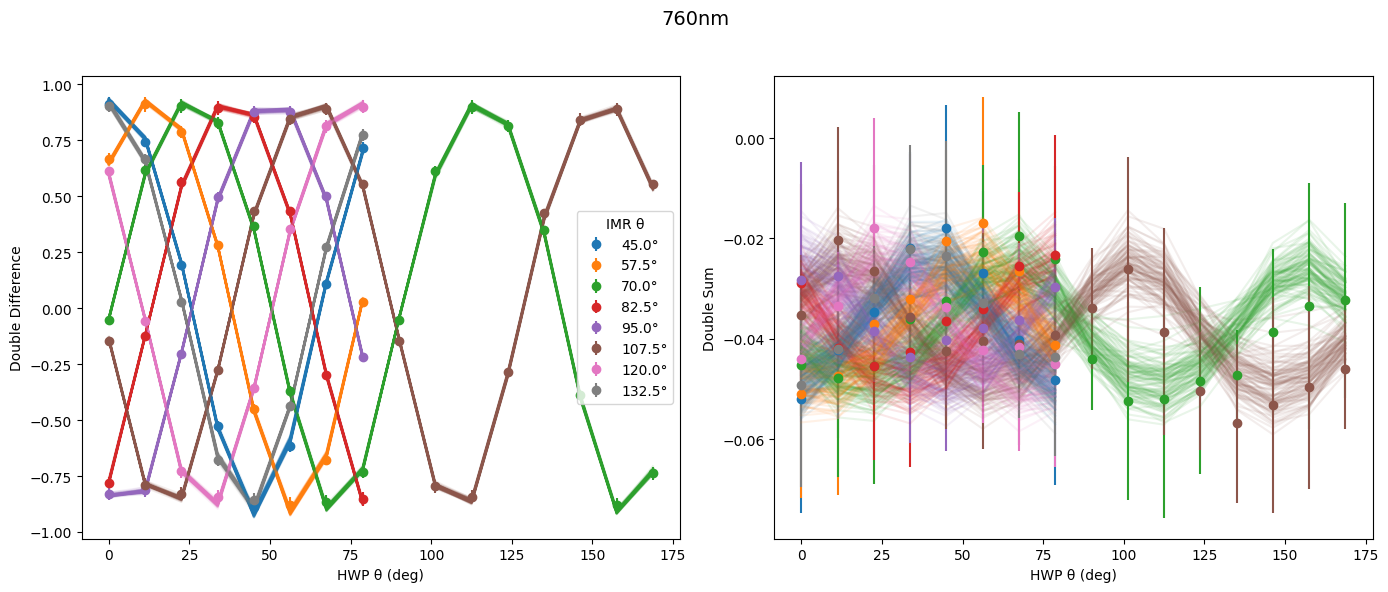

In [9]:
import importlib
inst = importlib.reload(inst)

# User settings
n_random_chains = 100
random_chain_step_range = corner_plot_step_range
random_chain_alpha = 0.1
random_seed = 42
imr_theta_filter = None

with open(txt_file_path, "r") as f:
    fit_param_dict = json.load(f)
_, fit_param_keys = inst.parse_configuration(fit_param_dict)

start, end = random_chain_step_range
if end is None:
    end = chain.shape[0]

if start < 0 or end > chain.shape[0] or start >= end:
    raise ValueError(f"Invalid random_chain_step_range {random_chain_step_range} for chain with {chain.shape[0]} steps.")

chain_window = chain[start:end, :, :]
flat_chain_window = chain_window.reshape(-1, chain.shape[-1])
n_available_samples = flat_chain_window.shape[0]

if chain.shape[-1] < len(fit_param_keys):
    raise ValueError(f"Chain has {chain.shape[-1]} parameters, but {len(fit_param_keys)} fitted parameters were found.")

if n_random_chains > n_available_samples:
    raise ValueError(f"Only {n_available_samples} samples available, but {n_random_chains} requested.")

rng = np.random.default_rng(random_seed)
selected_flat_indices = rng.choice(n_available_samples, size=n_random_chains, replace=False)
selected_steps = start + (selected_flat_indices // chain.shape[1])
selected_walkers = selected_flat_indices % chain.shape[1]
random_chain_samples = flat_chain_window[selected_flat_indices, :len(fit_param_keys)]
random_chain_system_mm = inst.generate_system_mueller_matrix(system_dict)
s_in_random = globals().get("s_in", np.array([1, 0, 0, 0]))

random_chain_models = [
    inst.model(
        sample,
        fit_param_keys,
        random_chain_system_mm,
        configuration_list,
        s_in=s_in_random,
        process_model=inst.process_model,
    )
    for sample in random_chain_samples
]

print(f"Plotting {n_random_chains} random chain samples from steps {start} to {end}.")
print("Selected (step, walker) pairs:")
print(list(zip(selected_steps.tolist(), selected_walkers.tolist())))

inst.plot_data_and_model(
    interleaved_values,
    interleaved_stds,
    random_chain_models,
    configuration_list,
    wavelength=wavelength_string,
    imr_theta_filter=imr_theta_filter,
    model_alpha=random_chain_alpha,
    first_model_alpha=random_chain_alpha,
)


In [10]:
# import sys
# import os

# # Add the directory containing instruments.py to the Python path
# custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
# sys.path.append(custom_module_path)

# import plotting_rewrite as plotting
# import numpy as np

# all_step_range = (0, None)
# corner_plot_step_range = (24000, 25000)

# # Define the system configuration dictionary
# system_dict = {
#     "components": {
#         "wollaston": {
#             "type": "wollaston_prism_function",
#             "properties": {"beam": "o", "transmission_ratio": 1.18},
#         },
#         "dichroic": {
#             "type": "diattenuator_retarder_function",
#             "properties": {"phi": 0, "epsilon": 0, "theta": 0},
#         },
#         "flc": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
#         },
#         "optics": {
#             "type": "diattenuator_retarder_function",
#             "properties": {"phi": 0, "epsilon": 0, "theta": 0},
#         },
#         "image_rotator": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
#         },
#         "hwp": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5, "theta": 0, "delta_theta": 0},
#         },
#         "lp": {
#             "type": "general_linear_polarizer_function_with_theta",
#             "properties": {"theta": 0},
#         },
#     }
# }

# # Input paths and call plotting function
# h5_filename = "675nm_no_IMR_offset_with_dichroic.h5"
# txt_filename = "675-50nm.txt"
# csv_file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"

# plotting.plot_mcmc_fits_double_diff_sum(
#     h5_filename=h5_filename,
#     txt_filename=txt_filename,
#     csv_path=csv_file_path,
#     filter_wavelength="675-50",
#     system_dict=system_dict,
#     wavelength_str="675nm",
#     n_samples=50,
#     step_range = all_step_range
# )
